In [1]:
import h5py
import numpy as np
CRYSTAL = h5py.File('EELS_3D-out/EELS_3D_CRYSTAL_2D-ex.h5')
EMPTY = h5py.File('EELS_3D-out/EELS_3D_EMPTY_2D-ex.h5')

In [2]:
q_e = 1.60217646e-19

In [3]:
Esim_crystal    = CRYSTAL['ex']     # NOT normalized E field in MEEP units
FLUXsim_crystal = CRYSTAL['flux']   # Electric field flux in MEEP units
Esim_empty      = EMPTY['ex']       # NOT normalized E field in MEEP units
FLUXsim_empty   = EMPTY['flux']     # Electric field flux in MEEP units

In [4]:
crystal = Esim_crystal[()]
empty   = Esim_empty[()]

In [5]:
# Normalization factor alpha
alpha_crystal = -q_e/FLUXsim_crystal[()]
alpha_empty   = -q_e/FLUXsim_empty[()]

crystal = alpha_crystal*Esim_crystal[()]    # Electric field for 1 electron in MEEP units
empty   = alpha_empty*Esim_empty[()]        # Electric field for 1 electron in MEEP units

In [6]:
crystal

array([[ 7.79298050e-18,  8.07965116e-18,  7.91868683e-18, ...,
         1.24833093e-18,  5.79815212e-19,  3.02681422e-19],
       [-6.10677975e-18, -2.27424276e-18,  3.25193527e-18, ...,
         2.95744090e-19,  5.81657127e-19,  1.46014548e-18],
       [-5.17625282e-18, -5.89960159e-18, -7.73684544e-18, ...,
         1.07481860e-18,  1.45231213e-18,  1.03707496e-18],
       ...,
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
         7.40386696e-18,  7.86222419e-18,  8.84874436e-18],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
        -4.26525946e-18,  1.82162614e-20,  5.40268037e-18],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
        -4.27530161e-18, -6.49823255e-18, -8.42121255e-18]],
      shape=(866, 3152))

In [7]:
empty

array([[ 8.32221184e-18,  8.65804184e-18,  8.57352661e-18, ...,
         7.27535609e-19,  7.14973417e-19,  7.73437012e-19],
       [-5.75606008e-18, -1.89664416e-18,  3.69252175e-18, ...,
         1.05038979e-18,  1.03156753e-18,  1.11782330e-18],
       [-5.32243829e-18, -6.00033419e-18, -7.71484448e-18, ...,
         9.31708136e-19,  9.15015899e-19,  9.92913414e-19],
       ...,
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
         7.59894430e-18,  7.59055362e-18,  7.79273082e-18],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
        -4.57568969e-18,  7.19746912e-20,  4.71221437e-18],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
        -6.59993223e-18, -7.68737412e-18, -8.72036265e-18]],
      shape=(866, 3152))

In [8]:
diff = crystal - empty  # Eind in MEEP units
diff

array([[-5.29231345e-19, -5.78390681e-19, -6.54839780e-19, ...,
         5.20795325e-19, -1.35158205e-19, -4.70755589e-19],
       [-3.50719668e-19, -3.77598598e-19, -4.40586481e-19, ...,
        -7.54645699e-19, -4.49910406e-19,  3.42322179e-19],
       [ 1.46185475e-19,  1.00732601e-19, -2.20009566e-20, ...,
         1.43110462e-19,  5.37296232e-19,  4.41615474e-20],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -1.95077347e-19,  2.71670575e-19,  1.05601354e-18],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         3.10430229e-19, -5.37584298e-20,  6.90466000e-19],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         2.32463062e-18,  1.18914157e-18,  2.99150095e-19]],
      shape=(866, 3152))

In [9]:
with h5py.File("crystal_PML_a36-r245-ex.hdf5", "w") as f:
    dset = f.create_dataset("ex", empty.shape, dtype='<f8', data=crystal)

In [10]:
with h5py.File("empty_PML_a36-ex.hdf5", "w") as f:
    dset = f.create_dataset("ex", crystal.shape, dtype='<f8', data=empty)

In [11]:
with h5py.File("diff_PML_a36-r245.hdf5", "w") as f:
    dset = f.create_dataset("ex", diff.shape, dtype='<f8', data=diff)

# Check how the flux changes over time

In [12]:
import matplotlib.pyplot as plt

In [13]:
t = np.arange(0,len(FLUXsim_crystal))

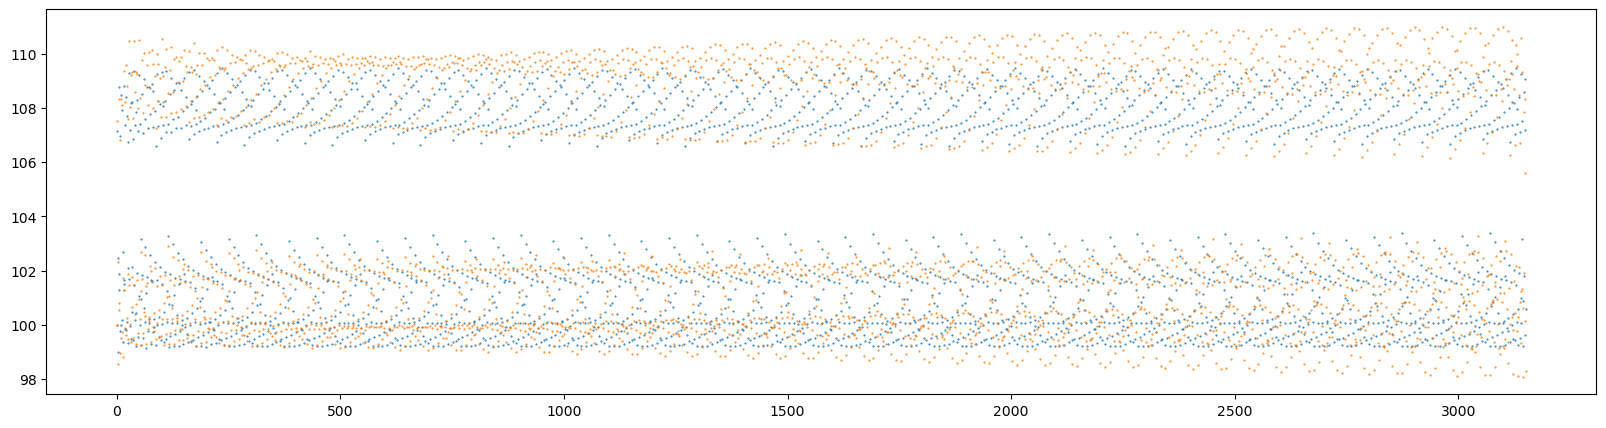

In [14]:
plt.figure(figsize=(20,5))
plt.plot(t, FLUXsim_empty[()]/FLUXsim_empty[0]*100, '.', ms=1)
plt.plot(t, FLUXsim_crystal[()]/FLUXsim_crystal[0]*100, '.', ms=1)